In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import *
import warnings
warnings.filterwarnings('ignore')

!pip install ydata-profiling
from ydata_profiling import ProfileReport

In [2]:
data=pd.read_csv('auto_imports.csv')
data

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [3]:
data.rename(columns={'3':'Symboling','?':'Normalized_losses','alfa-romero':'Make','gas':'Fuel_Type','std':
                    'Aspiration','two':'Num_of_Doors','convertible':'Body_Style','rwd':'Drive_Wheels',
                    'front':'Engine_Location','88.60':'Wheel_Base','168.80':'Length','64.10':'Width',
                    '48.80':'Height','2548':'Curb_Weight','dohc':'Engine_Type','four':'Number_of_Cylinders',
                    '130':'Engine_Size','mpfi':'Fuel_System','3.47':'Bore','2.68':'Stroke',
                    '9.00':'Compression_Ratio','111':'Horsepower','5000':'Peak_rpm','21':'City_mpg',
                    '27':'Highway_mpg','13495':'Price'},inplace=True)


In [4]:
data

,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Wheel_Base,...,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [5]:
data.head(10)

,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Wheel_Base,...,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
5,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
6,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
7,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
8,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16430
9,0,192,bmw,gas,std,four,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16925


In [6]:
data.tail(10)

,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Wheel_Base,...,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
190,-1,74,volvo,gas,std,four,wagon,rwd,front,104.3,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,13415
191,-2,103,volvo,gas,std,four,sedan,rwd,front,104.3,...,141,mpfi,3.78,3.15,9.5,114,5400,24,28,15985
192,-1,74,volvo,gas,std,four,wagon,rwd,front,104.3,...,141,mpfi,3.78,3.15,9.5,114,5400,24,28,16515
193,-2,103,volvo,gas,turbo,four,sedan,rwd,front,104.3,...,130,mpfi,3.62,3.15,7.5,162,5100,17,22,18420
194,-1,74,volvo,gas,turbo,four,wagon,rwd,front,104.3,...,130,mpfi,3.62,3.15,7.5,162,5100,17,22,18950
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470
199,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


In [7]:
pd.set_option('display.max_columns',None)
data

,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Type,Number_of_Cylinders,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [8]:
data.columns

Index(['Symboling', 'Normalized_losses', 'Make', 'Fuel_Type', 'Aspiration',
       'Num_of_Doors', 'Body_Style', 'Drive_Wheels', 'Engine_Location',
       'Wheel_Base', 'Length', 'Width', 'Height', 'Curb_Weight', 'Engine_Type',
       'Number_of_Cylinders', 'Engine_Size', 'Fuel_System', 'Bore', 'Stroke',
       'Compression_Ratio', 'Horsepower', 'Peak_rpm', 'City_mpg',
       'Highway_mpg', 'Price'],
      dtype='object')

In [9]:
data.shape

(200, 26)

In [10]:
data.index

RangeIndex(start=0, stop=200, step=1)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Symboling            200 non-null    int64  
 1   Normalized_losses    200 non-null    object 
 2   Make                 200 non-null    object 
 3   Fuel_Type            200 non-null    object 
 4   Aspiration           200 non-null    object 
 5   Num_of_Doors         200 non-null    object 
 6   Body_Style           200 non-null    object 
 7   Drive_Wheels         200 non-null    object 
 8   Engine_Location      200 non-null    object 
 9   Wheel_Base           200 non-null    float64
 10  Length               200 non-null    float64
 11  Width                200 non-null    float64
 12  Height               200 non-null    float64
 13  Curb_Weight          200 non-null    int64  
 14  Engine_Type          200 non-null    object 
 15  Number_of_Cylinders  200 non-null    obj

In [12]:
data.describe()

,Symboling,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Size,Compression_Ratio,City_mpg,Highway_mpg,Price
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.830000,98.848000,174.228000,65.898000,53.791500,2555.705000,126.860000,10.170100,25.200000,30.705000,13205.690000
std,1.248557,6.038261,12.347132,2.102904,2.428449,518.594552,41.650501,4.014163,6.432487,6.827227,7966.982558
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.675000,64.175000,52.000000,2163.000000,97.750000,8.575000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,119.500000,9.000000,24.000000,30.000000,10270.000000
75%,2.000000,102.400000,183.500000,66.675000,55.525000,2928.250000,142.000000,9.400000,30.000000,34.000000,16500.750000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [13]:
data.describe(include='O')

,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Engine_Type,Number_of_Cylinders,Fuel_System,Bore,Stroke,Horsepower,Peak_rpm
count,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200
unique,52,22,2,2,3,5,3,2,6,7,8,39,37,59,23
top,?,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi,3.62,3.40,68,5500
freq,36,32,180,164,113,94,118,197,145,156,91,23,19,19,36


HANDLING CORRUPTED VALUES

In [14]:
column_corrupted= data.columns[(data == '?').any()].tolist()
column_corrupted

['Normalized_losses',
 'Num_of_Doors',
 'Bore',
 'Stroke',
 'Horsepower',
 'Peak_rpm']

In [15]:
data['Stroke'] = data['Stroke'].replace('?', pd.to_numeric(data['Stroke'], errors='coerce').median())
data['Stroke']=data['Stroke'].astype(float)
data['Horsepower'] = data['Horsepower'].replace('?', pd.to_numeric(data['Horsepower'], errors='coerce').median())
data['Horsepower']=data['Horsepower'].astype(int)
data['Peak_rpm'] = data['Peak_rpm'].replace('?', pd.to_numeric(data['Peak_rpm'], errors='coerce').median())
data['Peak_rpm']=data['Peak_rpm'].astype(int)
data['Num_of_Doors'].replace('?',data['Num_of_Doors'].mode()[0],inplace=True)

In [16]:
column_corrupted= data.columns[(data == '?').any()].tolist()
column_corrupted

['Normalized_losses', 'Bore']

In [17]:
data['Normalized_losses'] = data['Normalized_losses'].replace('?', pd.to_numeric(data['Normalized_losses'], errors='coerce').median())
data['Normalized_losses']=data['Normalized_losses'].astype(int)
data['Bore'] = data['Bore'].replace('?', pd.to_numeric(data['Bore'], errors='coerce').median())
data['Bore']=data['Bore'].astype(float)

In [18]:
column_corrupted= data.columns[(data == '?').any()].tolist()
column_corrupted

[]

## EXPLORATORY DATA ANALYSIS (EDA)
PROFILE REPORT

In [ ]:
report=ProfileReport(data,title="ProfileReport")
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                                                               | 0/54 [00:00<?, ?it/s]
%|████▍                                                                                                                  | 2/54 [00:00<00:05, 10.09it/s]
%|████████▊                                                                                                              | 4/54 [00:00<00:04, 10.62it/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 59.57it/s]


UNIVARIATE ANALYSIS FOR NUMERICAL COLUMNS

In [19]:
numerical_col = data.select_dtypes(include=["int","float"]).columns
numerical_col

Index(['Symboling', 'Normalized_losses', 'Wheel_Base', 'Length', 'Width',
       'Height', 'Curb_Weight', 'Engine_Size', 'Bore', 'Stroke',
       'Compression_Ratio', 'Horsepower', 'Peak_rpm', 'City_mpg',
       'Highway_mpg', 'Price'],
      dtype='object')

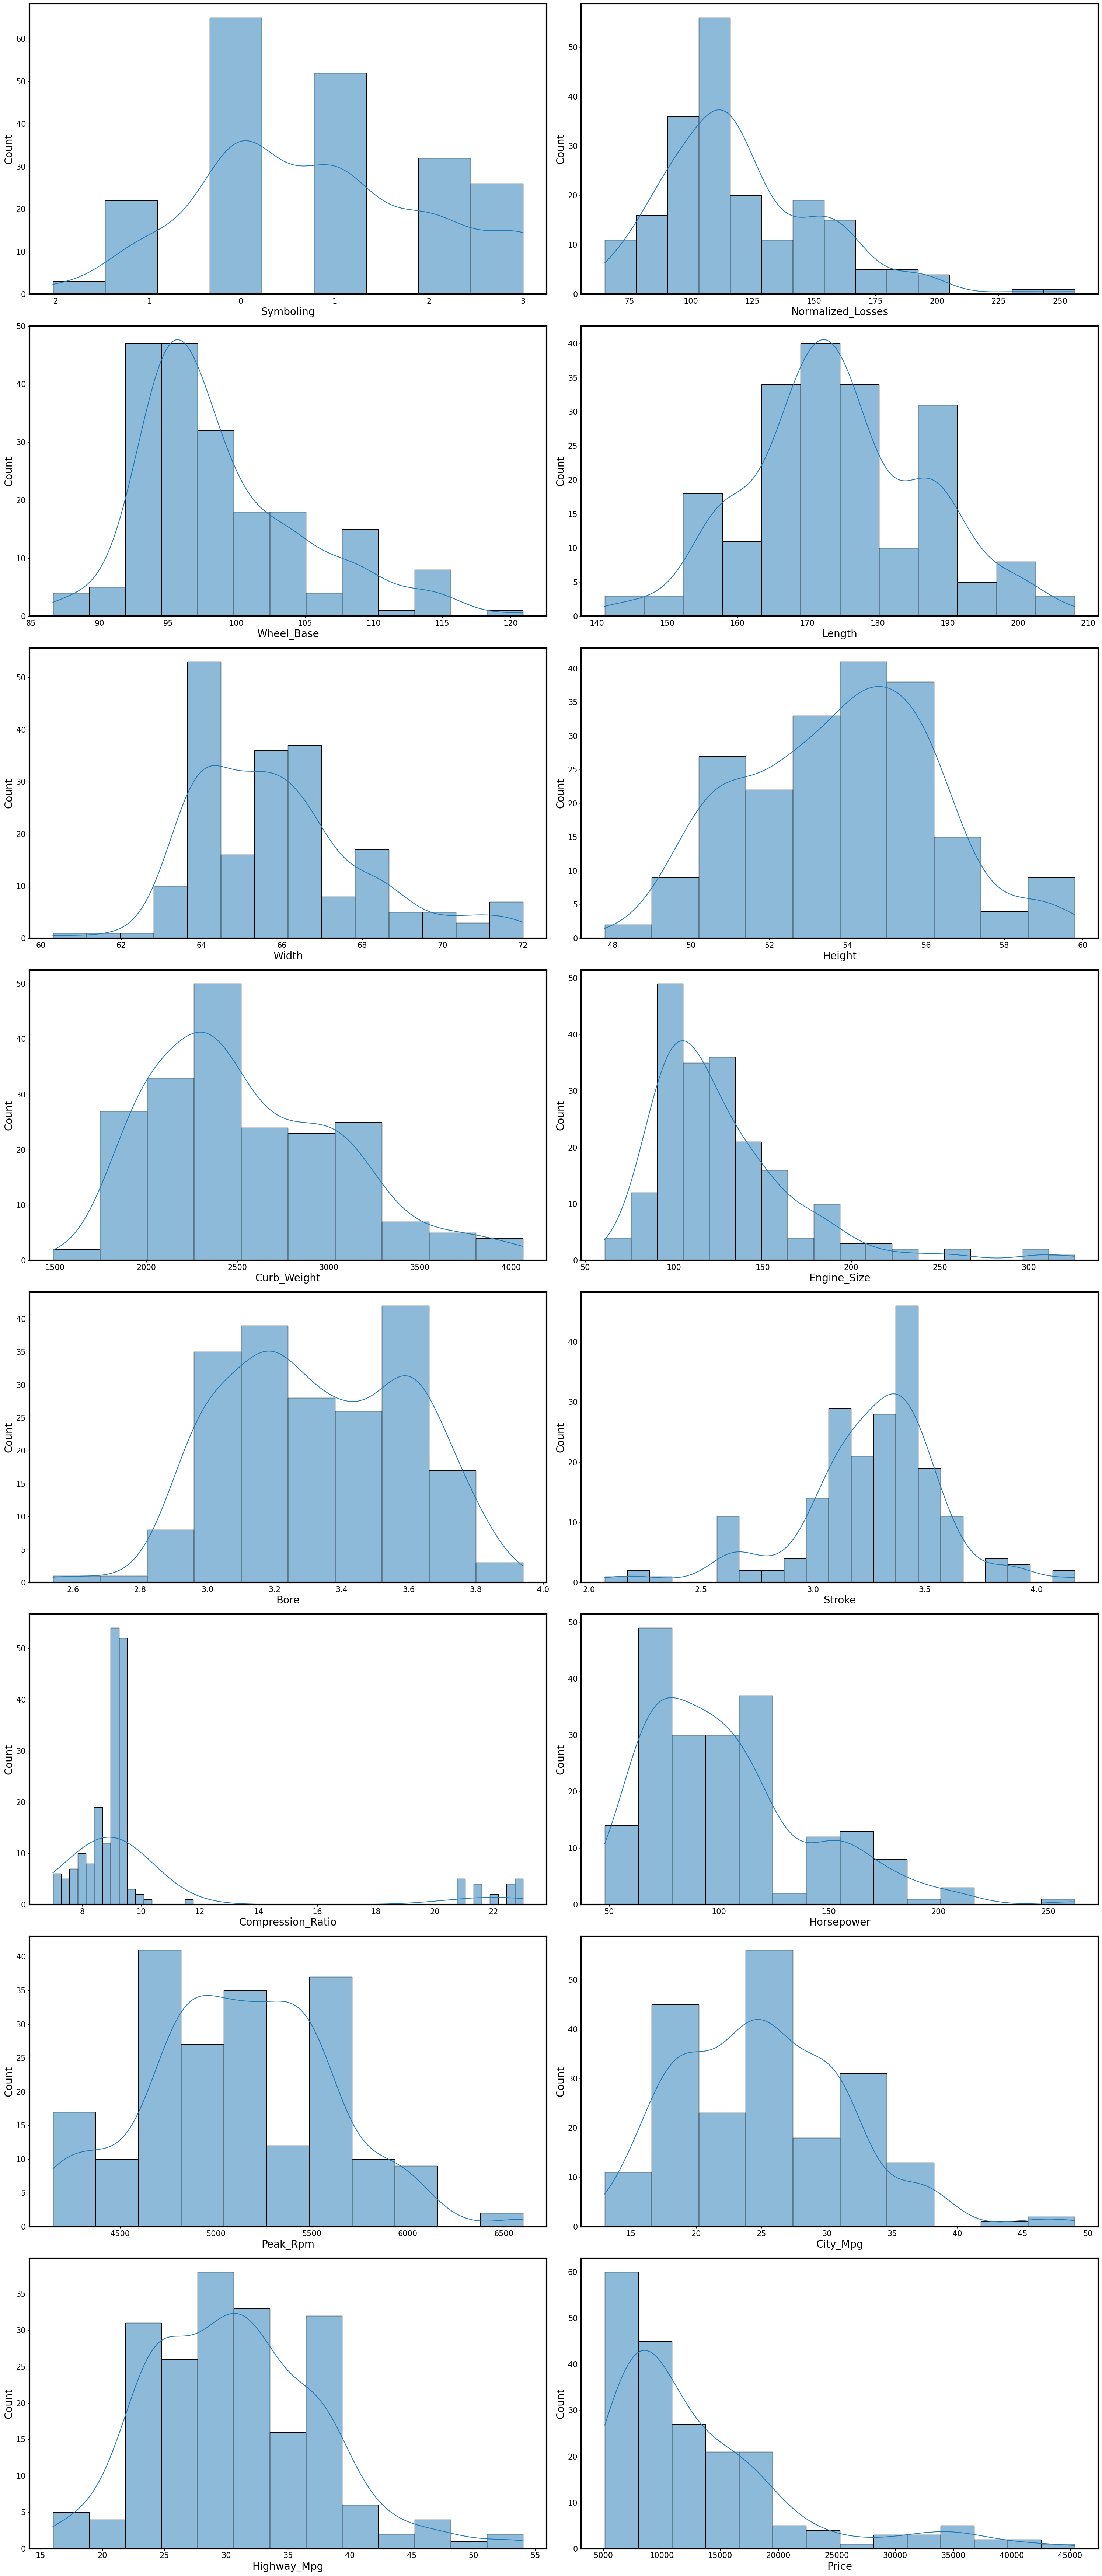

In [20]:
plt.figure(figsize=(30,70),facecolor="white")
pltnum =1

for i in numerical_col:
    if pltnum <=16:
        sp = plt.subplot(8,2,pltnum)
        sns.histplot(data[i],kde=True)
        plt.xlabel(i.title(),fontsize=20)
        plt.ylabel("Count",fontsize=20)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        sp.spines['top'].set_linewidth(3)
        sp.spines['bottom'].set_linewidth(3)
        sp.spines['left'].set_linewidth(3)
        sp.spines['right'].set_linewidth(3)
    pltnum +=1
plt.tight_layout()
plt.show()

UNIVARIATE ANALYSIS FOR CATEGORICAL COLUMNS

In [21]:
category_col = data.select_dtypes(include=["object"]).columns
category_col

Index(['Make', 'Fuel_Type', 'Aspiration', 'Num_of_Doors', 'Body_Style',
       'Drive_Wheels', 'Engine_Location', 'Engine_Type', 'Number_of_Cylinders',
       'Fuel_System'],
      dtype='object')

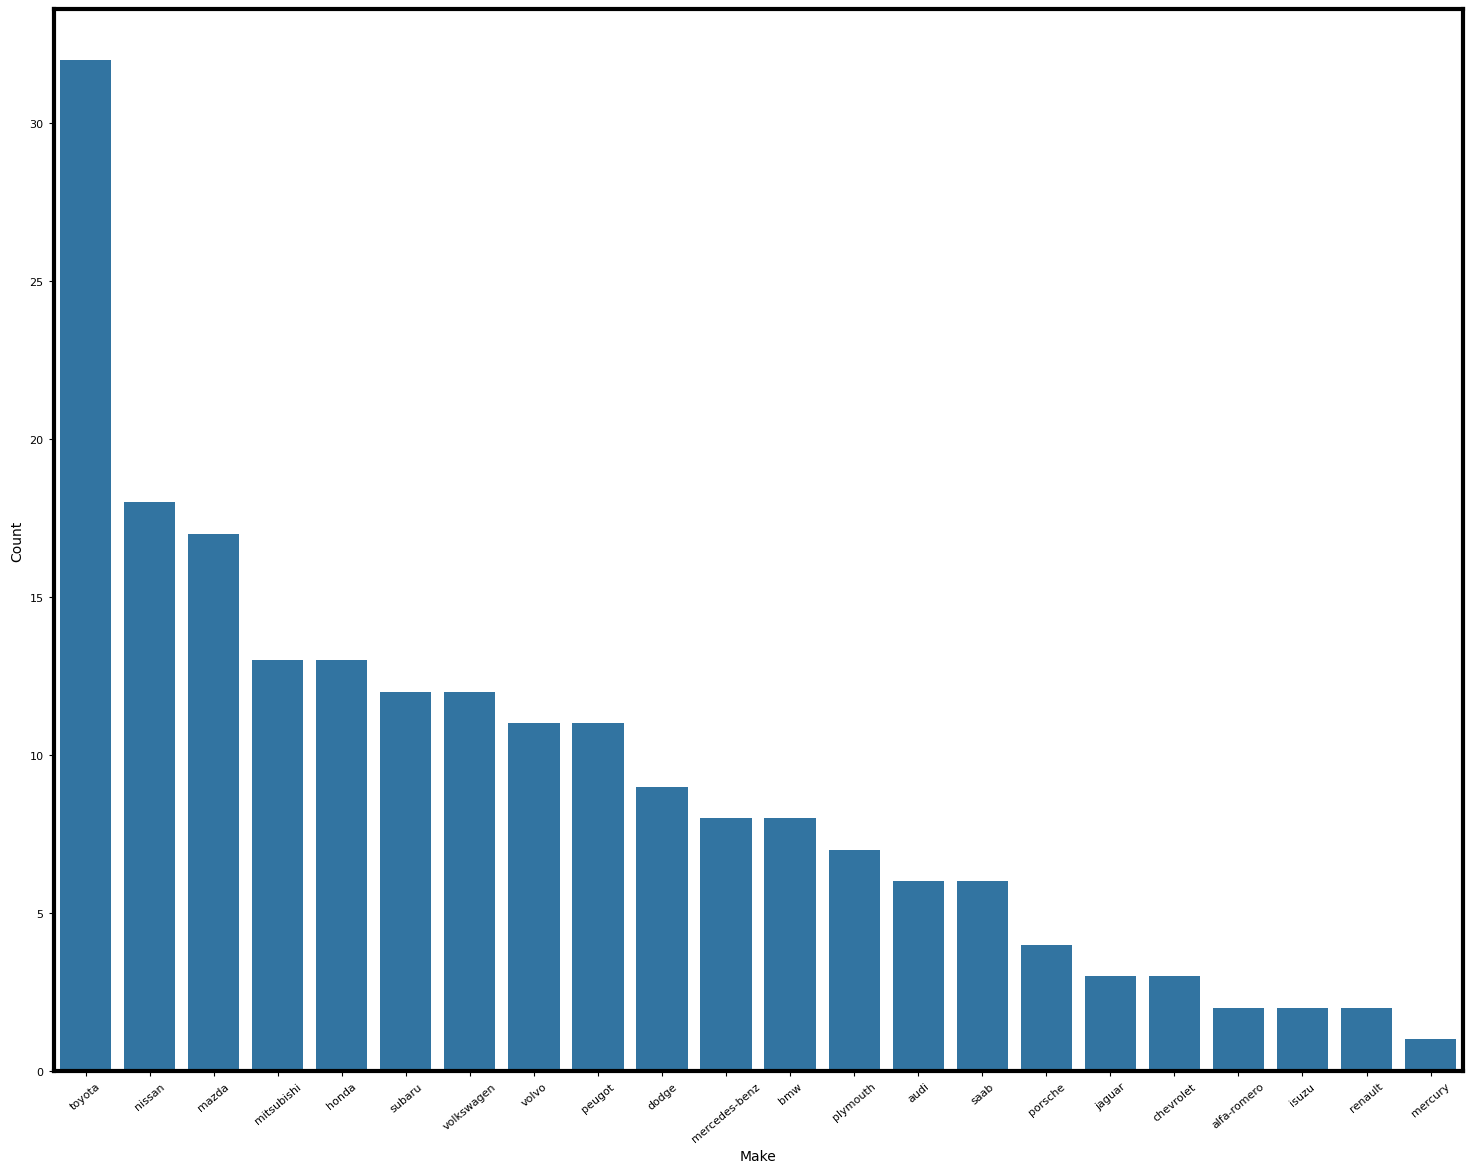

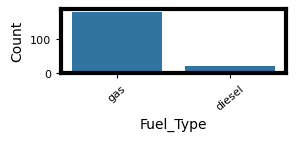

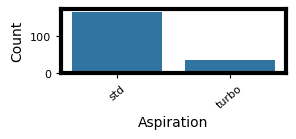

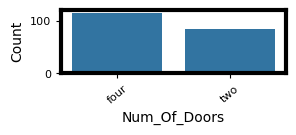

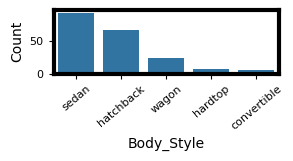

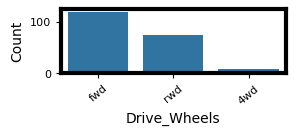

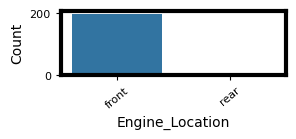

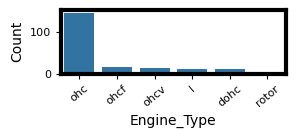

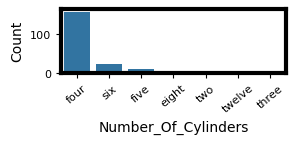

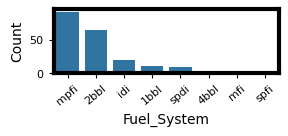

In [22]:
plt.figure(figsize=(40,80),facecolor="white")
pltnum=1
for i in category_col:
    if pltnum <= 10:
        sp = plt.subplot(5, 2, pltnum)
        sns.barplot(x=data[i].value_counts().index, y=data[i].value_counts().values)
        plt.xlabel(i.title(), fontsize=10)
        plt.ylabel("Count", fontsize=10)
        plt.xticks(rotation=40, fontsize=8)  
        plt.yticks(fontsize=8)  
        sp.spines['top'].set_linewidth(3)
        sp.spines['bottom'].set_linewidth(3)
        sp.spines['left'].set_linewidth(3)
        sp.spines['right'].set_linewidth(3)

    pltnum += 1 
    plt.show()

BIVARIATE ANALYSIS

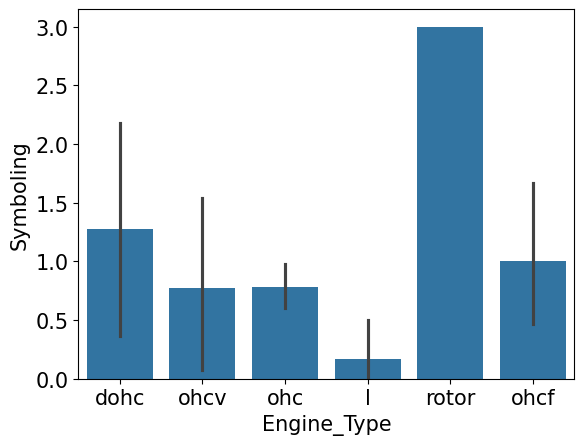

In [23]:
sns.barplot(data,x="Engine_Type",y="Symboling")
plt.xlabel("Engine_Type",fontsize=15)
plt.ylabel("Symboling",fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()


In [24]:
plt.figure(figsize=(100,80))
sns.barplot(data,x="Make",y="Horsepower")
plt.xlabel("Make",fontsize=70)
plt.ylabel("Horsepower",fontsize=70)
plt.xticks(rotation=45,fontsize=50)
plt.yticks(fontsize=50)
plt.show()

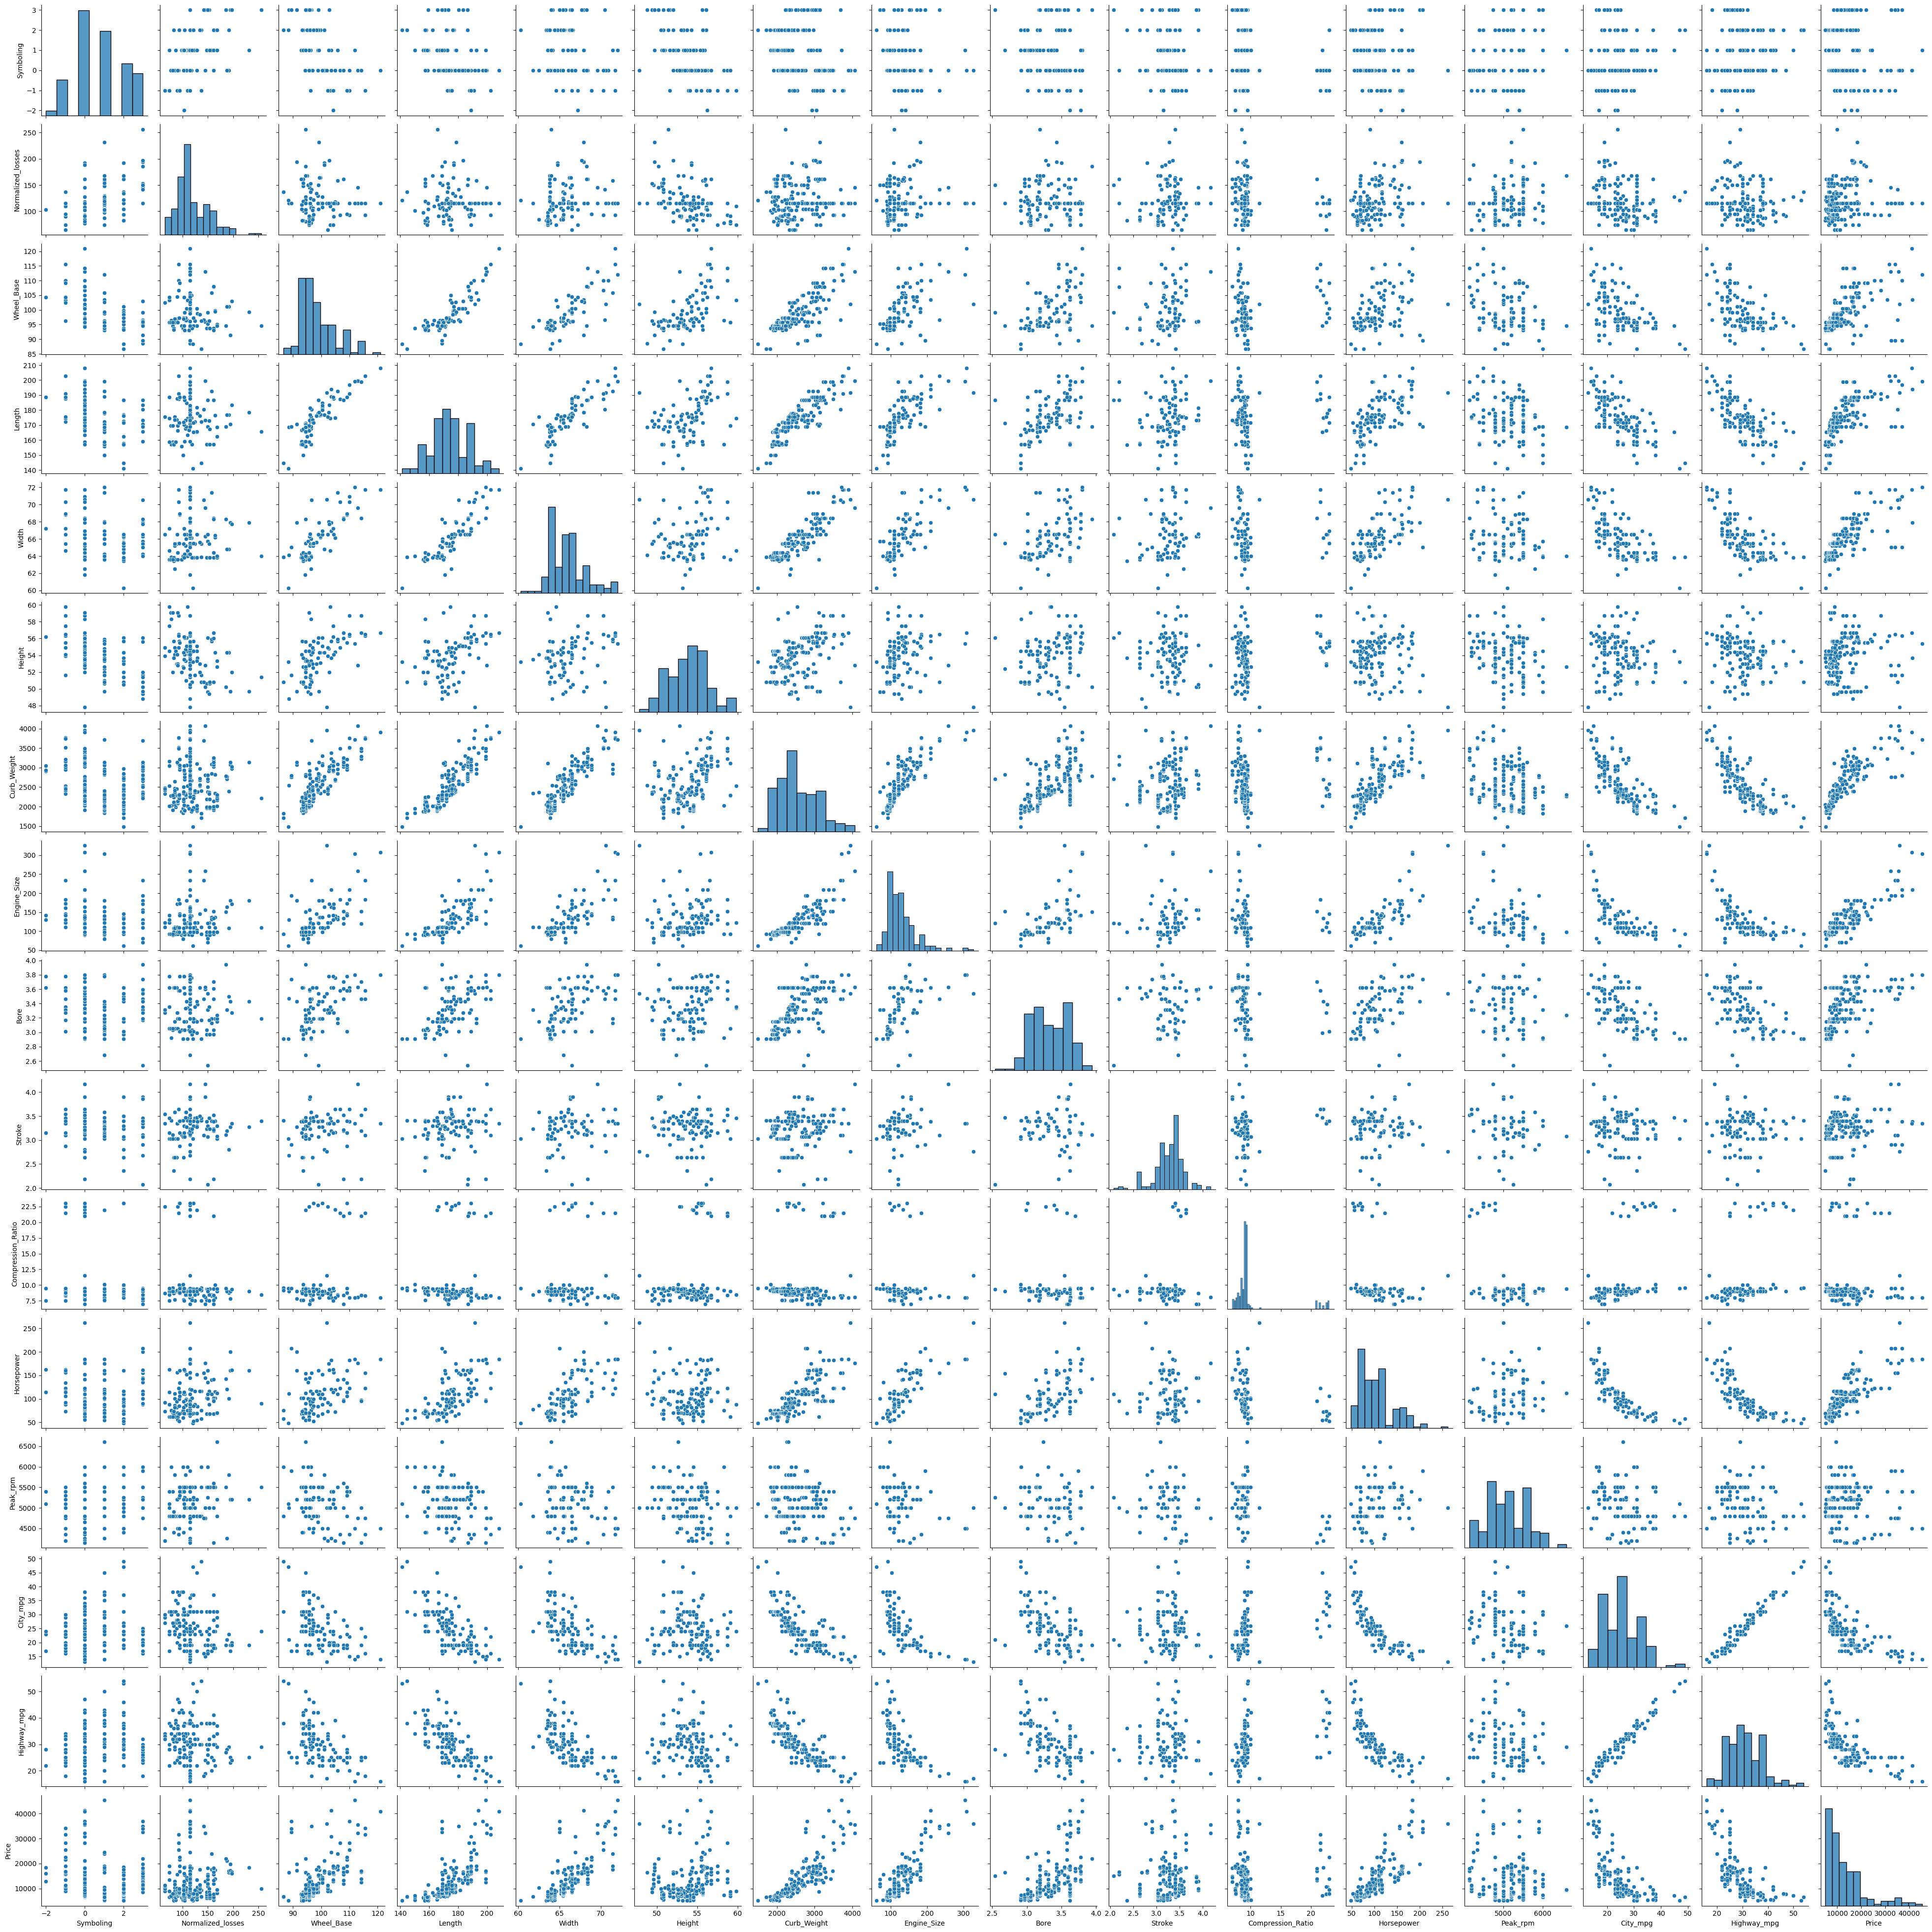

In [25]:
sns.pairplot(data)
plt.show()

#DATA PREPROCESSING

In [26]:
data.isnull().sum()

Symboling              0
Normalized_losses      0
Make                   0
Fuel_Type              0
Aspiration             0
Num_of_Doors           0
Body_Style             0
Drive_Wheels           0
Engine_Location        0
Wheel_Base             0
Length                 0
Width                  0
Height                 0
Curb_Weight            0
Engine_Type            0
Number_of_Cylinders    0
Engine_Size            0
Fuel_System            0
Bore                   0
Stroke                 0
Compression_Ratio      0
Horsepower             0
Peak_rpm               0
City_mpg               0
Highway_mpg            0
Price                  0
dtype: int64

In [27]:
data.duplicated().sum()

np.int64(0)

In [28]:
from sklearn.preprocessing import LabelEncoder
Le = LabelEncoder()
for column in ['Fuel_Type', 'Aspiration', 'Num_of_Doors', 'Engine_Location']:
    data[column] = data[column].fillna('Unknown')
    data[column] = Le.fit_transform(data[column])


In [29]:
data

,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Body_Style,Drive_Wheels,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Type,Number_of_Cylinders,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,3,115,alfa-romero,1,0,1,convertible,rwd,0,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,115,alfa-romero,1,0,1,hatchback,rwd,0,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,1,0,0,sedan,fwd,0,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,1,0,0,sedan,4wd,0,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,115,audi,1,0,1,sedan,fwd,0,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95,volvo,1,0,0,sedan,rwd,0,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,1,1,0,sedan,rwd,0,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,1,0,0,sedan,rwd,0,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,0,1,0,sedan,rwd,0,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [30]:
from sklearn.preprocessing import OneHotEncoder
Ohe_Body_style = OneHotEncoder()
Body_Style_encoded = Ohe_Body_style.fit_transform(data[["Body_Style"]]).toarray()
Body_Style_encoded

array([[1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0.

In [31]:
Ohe_Body_style.get_feature_names_out()

array(['Body_Style_convertible', 'Body_Style_hardtop',
       'Body_Style_hatchback', 'Body_Style_sedan', 'Body_Style_wagon'],
      dtype=object)

In [32]:
Body_Style_encoded_df = pd.DataFrame(Body_Style_encoded.astype(int), index=data.index, columns=['Body_Style_convertible', 'Body_Style_hardtop',
       'Body_Style_hatchback', 'Body_Style_sedan', 'Body_Style_wagon'])
Body_Style_encoded_df

,Body_Style_convertible,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon
0,1,0,0,0,0
1,0,0,1,0,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0
...,...,...,...,...,...
195,0,0,0,1,0
196,0,0,0,1,0
197,0,0,0,1,0
198,0,0,0,1,0


In [33]:
Body_Style_encoded_df.drop('Body_Style_convertible',axis=1,inplace=True)
Body_Style_encoded_df

,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon
0,0,0,0,0
1,0,1,0,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0
...,...,...,...,...
195,0,0,1,0
196,0,0,1,0
197,0,0,1,0
198,0,0,1,0


In [34]:
data = pd.concat([Body_Style_encoded_df,data],axis=1)
data.drop("Body_Style",axis=1,inplace=True)
data

,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Drive_Wheels,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Type,Number_of_Cylinders,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,0,0,0,0,3,115,alfa-romero,1,0,1,rwd,0,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,0,1,0,0,1,115,alfa-romero,1,0,1,rwd,0,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,0,0,1,0,2,164,audi,1,0,0,fwd,0,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,0,0,1,0,2,164,audi,1,0,0,4wd,0,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,0,0,1,0,2,115,audi,1,0,1,fwd,0,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,1,0,-1,95,volvo,1,0,0,rwd,0,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,0,0,1,0,-1,95,volvo,1,1,0,rwd,0,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,0,0,1,0,-1,95,volvo,1,0,0,rwd,0,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,0,0,1,0,-1,95,volvo,0,1,0,rwd,0,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [35]:
Ohe_Drive_Wheels = OneHotEncoder()
Drive_Wheels_encoded = Ohe_Drive_Wheels.fit_transform(data[["Drive_Wheels"]]).toarray()
Drive_Wheels_encoded

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1

In [36]:
Ohe_Drive_Wheels.get_feature_names_out()

array(['Drive_Wheels_4wd', 'Drive_Wheels_fwd', 'Drive_Wheels_rwd'],
      dtype=object)

In [37]:
Drive_Wheels_encoded_df = pd.DataFrame(Drive_Wheels_encoded.astype(int), index=data.index, columns=['Drive_Wheels_4wd', 'Drive_Wheels_fwd', 'Drive_Wheels_rwd'])
Drive_Wheels_encoded_df

,Drive_Wheels_4wd,Drive_Wheels_fwd,Drive_Wheels_rwd
0,0,0,1
1,0,0,1
2,0,1,0
3,1,0,0
4,0,1,0
...,...,...,...
195,0,0,1
196,0,0,1
197,0,0,1
198,0,0,1


In [38]:
Drive_Wheels_encoded_df.drop('Drive_Wheels_4wd',axis=1,inplace=True)
Drive_Wheels_encoded_df

,Drive_Wheels_fwd,Drive_Wheels_rwd
0,0,1
1,0,1
2,1,0
3,0,0
4,1,0
...,...,...
195,0,1
196,0,1
197,0,1
198,0,1


In [39]:
data = pd.concat([Drive_Wheels_encoded_df,data],axis=1)
data.drop("Drive_Wheels",axis=1,inplace=True)
data 

,Drive_Wheels_fwd,Drive_Wheels_rwd,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Type,Number_of_Cylinders,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,0,1,0,0,0,0,3,115,alfa-romero,1,0,1,0,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,0,1,0,1,0,0,1,115,alfa-romero,1,0,1,0,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,1,0,0,0,1,0,2,164,audi,1,0,0,0,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,0,0,0,0,1,0,2,164,audi,1,0,0,0,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,1,0,0,0,1,0,2,115,audi,1,0,1,0,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,1,0,0,1,0,-1,95,volvo,1,0,0,0,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,0,1,0,0,1,0,-1,95,volvo,1,1,0,0,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,0,1,0,0,1,0,-1,95,volvo,1,0,0,0,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,0,1,0,0,1,0,-1,95,volvo,0,1,0,0,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [40]:
Ohe_ENGINE_TYPE = OneHotEncoder()
engine_type_encoded = Ohe_ENGINE_TYPE.fit_transform(data[["Engine_Type"]]).toarray()
engine_type_encoded

array([[1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.]])

In [41]:
Ohe_ENGINE_TYPE.get_feature_names_out()

array(['Engine_Type_dohc', 'Engine_Type_l', 'Engine_Type_ohc',
       'Engine_Type_ohcf', 'Engine_Type_ohcv', 'Engine_Type_rotor'],
      dtype=object)

In [42]:
Engine_Type_encoded_df = pd.DataFrame(engine_type_encoded.astype(int), index=data.index, columns=['Engine_Type_dohc', 'Engine_Type_l', 'Engine_Type_ohc',
       'Engine_Type_ohcf', 'Engine_Type_ohcv', 'Engine_Type_rotor'])
Engine_Type_encoded_df

,Engine_Type_dohc,Engine_Type_l,Engine_Type_ohc,Engine_Type_ohcf,Engine_Type_ohcv,Engine_Type_rotor
0,1,0,0,0,0,0
1,0,0,0,0,1,0
2,0,0,1,0,0,0
3,0,0,1,0,0,0
4,0,0,1,0,0,0
...,...,...,...,...,...,...
195,0,0,1,0,0,0
196,0,0,1,0,0,0
197,0,0,0,0,1,0
198,0,0,1,0,0,0


In [43]:
Engine_Type_encoded_df.drop('Engine_Type_rotor',axis=1,inplace=True)
data = pd.concat([Engine_Type_encoded_df,data],axis=1)
data.drop("Engine_Type",axis=1,inplace=True)
data 

,Engine_Type_dohc,Engine_Type_l,Engine_Type_ohc,Engine_Type_ohcf,Engine_Type_ohcv,Drive_Wheels_fwd,Drive_Wheels_rwd,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Number_of_Cylinders,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,1,0,0,0,0,0,1,0,0,0,0,3,115,alfa-romero,1,0,1,0,88.6,168.8,64.1,48.8,2548,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,0,0,0,0,1,0,1,0,1,0,0,1,115,alfa-romero,1,0,1,0,94.5,171.2,65.5,52.4,2823,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,0,0,1,0,0,1,0,0,0,1,0,2,164,audi,1,0,0,0,99.8,176.6,66.2,54.3,2337,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,0,0,1,0,0,0,0,0,0,1,0,2,164,audi,1,0,0,0,99.4,176.6,66.4,54.3,2824,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,0,0,1,0,0,1,0,0,0,1,0,2,115,audi,1,0,1,0,99.8,177.3,66.3,53.1,2507,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,1,0,0,0,1,0,0,1,0,-1,95,volvo,1,0,0,0,109.1,188.8,68.9,55.5,2952,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,0,0,1,0,0,0,1,0,0,1,0,-1,95,volvo,1,1,0,0,109.1,188.8,68.8,55.5,3049,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,0,0,0,0,1,0,1,0,0,1,0,-1,95,volvo,1,0,0,0,109.1,188.8,68.9,55.5,3012,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,0,0,1,0,0,0,1,0,0,1,0,-1,95,volvo,0,1,0,0,109.1,188.8,68.9,55.5,3217,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [44]:
Ohe_NUM_CYL = OneHotEncoder()
Num_of_Cyl_encoded = Ohe_NUM_CYL.fit_transform(data[["Number_of_Cylinders"]]).toarray()
Num_of_Cyl_encoded

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [45]:
Ohe_NUM_CYL.get_feature_names_out()

array(['Number_of_Cylinders_eight', 'Number_of_Cylinders_five',
       'Number_of_Cylinders_four', 'Number_of_Cylinders_six',
       'Number_of_Cylinders_three', 'Number_of_Cylinders_twelve',
       'Number_of_Cylinders_two'], dtype=object)

In [46]:
num_cyl_encoded_df = pd.DataFrame(Num_of_Cyl_encoded.astype(int), index=data.index, columns=['Number_of_Cylinders_eight', 'Number_of_Cylinders_five',
       'Number_of_Cylinders_four', 'Number_of_Cylinders_six',
       'Number_of_Cylinders_three', 'Number_of_Cylinders_twelve',
       'Number_of_Cylinders_two'])
num_cyl_encoded_df

,Number_of_Cylinders_eight,Number_of_Cylinders_five,Number_of_Cylinders_four,Number_of_Cylinders_six,Number_of_Cylinders_three,Number_of_Cylinders_twelve,Number_of_Cylinders_two
0,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0
2,0,0,1,0,0,0,0
3,0,1,0,0,0,0,0
4,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...
195,0,0,1,0,0,0,0
196,0,0,1,0,0,0,0
197,0,0,0,1,0,0,0
198,0,0,0,1,0,0,0


In [47]:
num_cyl_encoded_df.drop(['Number_of_Cylinders_three','Number_of_Cylinders_twelve'],axis=1,inplace=True)
data = pd.concat([num_cyl_encoded_df,data],axis=1)
data.drop("Number_of_Cylinders",axis=1,inplace=True)
data

,Number_of_Cylinders_eight,Number_of_Cylinders_five,Number_of_Cylinders_four,Number_of_Cylinders_six,Number_of_Cylinders_two,Engine_Type_dohc,Engine_Type_l,Engine_Type_ohc,Engine_Type_ohcf,Engine_Type_ohcv,Drive_Wheels_fwd,Drive_Wheels_rwd,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Size,Fuel_System,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,3,115,alfa-romero,1,0,1,0,88.6,168.8,64.1,48.8,2548,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,1,115,alfa-romero,1,0,1,0,94.5,171.2,65.5,52.4,2823,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,2,164,audi,1,0,0,0,99.8,176.6,66.2,54.3,2337,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,2,164,audi,1,0,0,0,99.4,176.6,66.4,54.3,2824,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,2,115,audi,1,0,1,0,99.8,177.3,66.3,53.1,2507,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,-1,95,volvo,1,0,0,0,109.1,188.8,68.9,55.5,2952,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,-1,95,volvo,1,1,0,0,109.1,188.8,68.8,55.5,3049,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,-1,95,volvo,1,0,0,0,109.1,188.8,68.9,55.5,3012,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,-1,95,volvo,0,1,0,0,109.1,188.8,68.9,55.5,3217,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [48]:
Ohe_Fuel_sys = OneHotEncoder()
Fuel_Sys_encoded = Ohe_Fuel_sys.fit_transform(data[["Fuel_System"]]).toarray()
Fuel_Sys_encoded

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [49]:
Ohe_Fuel_sys.get_feature_names_out()

array(['Fuel_System_1bbl', 'Fuel_System_2bbl', 'Fuel_System_4bbl',
       'Fuel_System_idi', 'Fuel_System_mfi', 'Fuel_System_mpfi',
       'Fuel_System_spdi', 'Fuel_System_spfi'], dtype=object)

In [50]:
fuel_sys_encoded_df = pd.DataFrame(Fuel_Sys_encoded.astype(int), index=data.index, columns=['Fuel_System_1bbl', 'Fuel_System_2bbl', 'Fuel_System_4bbl',
       'Fuel_System_idi', 'Fuel_System_mfi', 'Fuel_System_mpfi',
       'Fuel_System_spdi', 'Fuel_System_spfi'])
fuel_sys_encoded_df

,Fuel_System_1bbl,Fuel_System_2bbl,Fuel_System_4bbl,Fuel_System_idi,Fuel_System_mfi,Fuel_System_mpfi,Fuel_System_spdi,Fuel_System_spfi
0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,1,0,0
2,0,0,0,0,0,1,0,0
3,0,0,0,0,0,1,0,0
4,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...
195,0,0,0,0,0,1,0,0
196,0,0,0,0,0,1,0,0
197,0,0,0,0,0,1,0,0
198,0,0,0,1,0,0,0,0


In [51]:
fuel_sys_encoded_df.drop(['Fuel_System_4bbl','Fuel_System_mfi','Fuel_System_spfi'],axis=1,inplace=True)
data = pd.concat([fuel_sys_encoded_df,data],axis=1)
data.drop("Fuel_System",axis=1,inplace=True)
data

,Fuel_System_1bbl,Fuel_System_2bbl,Fuel_System_idi,Fuel_System_mpfi,Fuel_System_spdi,Number_of_Cylinders_eight,Number_of_Cylinders_five,Number_of_Cylinders_four,Number_of_Cylinders_six,Number_of_Cylinders_two,Engine_Type_dohc,Engine_Type_l,Engine_Type_ohc,Engine_Type_ohcf,Engine_Type_ohcv,Drive_Wheels_fwd,Drive_Wheels_rwd,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Make,Fuel_Type,Aspiration,Num_of_Doors,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Size,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,3,115,alfa-romero,1,0,1,0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500
1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,1,115,alfa-romero,1,0,1,0,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500
2,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,2,164,audi,1,0,0,0,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950
3,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,2,164,audi,1,0,0,0,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450
4,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,2,115,audi,1,0,1,0,99.8,177.3,66.3,53.1,2507,136,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,-1,95,volvo,1,0,0,0,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114,5400,23,28,16845
196,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,-1,95,volvo,1,1,0,0,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160,5300,19,25,19045
197,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,-1,95,volvo,1,0,0,0,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134,5500,18,23,21485
198,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,-1,95,volvo,0,1,0,0,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106,4800,26,27,22470


In [52]:
Ohe_make = OneHotEncoder()
Make_encoded = Ohe_make.fit_transform(data[["Make"]]).toarray()
Make_encoded

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [53]:
Ohe_make.get_feature_names_out()

array(['Make_alfa-romero', 'Make_audi', 'Make_bmw', 'Make_chevrolet',
       'Make_dodge', 'Make_honda', 'Make_isuzu', 'Make_jaguar',
       'Make_mazda', 'Make_mercedes-benz', 'Make_mercury',
       'Make_mitsubishi', 'Make_nissan', 'Make_peugot', 'Make_plymouth',
       'Make_porsche', 'Make_renault', 'Make_saab', 'Make_subaru',
       'Make_toyota', 'Make_volkswagen', 'Make_volvo'], dtype=object)

In [54]:
MAKE_encoded_df = pd.DataFrame(Make_encoded.astype(int), index=data.index, columns=['Make_alfa-romero', 'Make_audi', 'Make_bmw', 'Make_chevrolet',
       'Make_dodge', 'Make_honda', 'Make_isuzu', 'Make_jaguar',
       'Make_mazda', 'Make_mercedes-benz', 'Make_mercury',
       'Make_mitsubishi', 'Make_nissan', 'Make_peugot', 'Make_plymouth',
       'Make_porsche', 'Make_renault', 'Make_saab', 'Make_subaru',
       'Make_toyota', 'Make_volkswagen', 'Make_volvo'])
MAKE_encoded_df

,Make_alfa-romero,Make_audi,Make_bmw,Make_chevrolet,Make_dodge,Make_honda,Make_isuzu,Make_jaguar,Make_mazda,Make_mercedes-benz,Make_mercury,Make_mitsubishi,Make_nissan,Make_peugot,Make_plymouth,Make_porsche,Make_renault,Make_saab,Make_subaru,Make_toyota,Make_volkswagen,Make_volvo
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
196,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
197,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
198,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [55]:
MAKE_encoded_df.drop(['Make_alfa-romero','Make_isuzu','Make_jaguar','Make_mercury','Make_chevrolet','Make_renault'],axis=1,inplace=True)

In [56]:
data = pd.concat([MAKE_encoded_df,data],axis=1)

In [57]:
data.drop("Make",axis=1,inplace=True)

In [58]:
data

,Make_audi,Make_bmw,Make_dodge,Make_honda,Make_mazda,Make_mercedes-benz,Make_mitsubishi,Make_nissan,Make_peugot,Make_plymouth,Make_porsche,Make_saab,Make_subaru,Make_toyota,Make_volkswagen,Make_volvo,Fuel_System_1bbl,Fuel_System_2bbl,Fuel_System_idi,Fuel_System_mpfi,Fuel_System_spdi,Number_of_Cylinders_eight,Number_of_Cylinders_five,Number_of_Cylinders_four,Number_of_Cylinders_six,Number_of_Cylinders_two,Engine_Type_dohc,Engine_Type_l,Engine_Type_ohc,Engine_Type_ohcf,Engine_Type_ohcv,Drive_Wheels_fwd,Drive_Wheels_rwd,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Fuel_Type,Aspiration,Num_of_Doors,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Size,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,3,115,1,0,1,0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,1,115,1,0,1,0,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,2,164,1,0,0,0,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,2,164,1,0,0,0,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,2,115,1,0,1,0,99.8,177.3,66.3,53.1,2507,136,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,-1,95,1,0,0,0,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114,5400,23,28,16845
196,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,-1,95,1,1,0,0,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160,5300,19,25,19045
197,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,-1,95,1,0,0,0,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134,5500,18,23,21485
198,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,-1,95,0,1,0,0,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106,4800,26,27,22470


SCALING FOR NUMERICAL COLUMNS¶

In [59]:
from sklearn.preprocessing import MinMaxScaler
mm= MinMaxScaler()
numericals_col=['Symboling', 'Normalized_losses', 'Wheel_Base',  'Width',
       'Height',  'Engine_Size', 'Bore', 'Stroke', 'Length', 'Curb_Weight', 'Highway_mpg',
       'Compression_Ratio', 'Horsepower', 'Peak_rpm', 'City_mpg', 'Price']
data[numericals_col] = mm.fit_transform(data[numericals_col])
data

,Make_audi,Make_bmw,Make_dodge,Make_honda,Make_mazda,Make_mercedes-benz,Make_mitsubishi,Make_nissan,Make_peugot,Make_plymouth,Make_porsche,Make_saab,Make_subaru,Make_toyota,Make_volkswagen,Make_volvo,Fuel_System_1bbl,Fuel_System_2bbl,Fuel_System_idi,Fuel_System_mpfi,Fuel_System_spdi,Number_of_Cylinders_eight,Number_of_Cylinders_five,Number_of_Cylinders_four,Number_of_Cylinders_six,Number_of_Cylinders_two,Engine_Type_dohc,Engine_Type_l,Engine_Type_ohc,Engine_Type_ohcf,Engine_Type_ohcv,Drive_Wheels_fwd,Drive_Wheels_rwd,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Fuel_Type,Aspiration,Num_of_Doors,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Size,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1.0,0.261780,1,0,1,0,0.058309,0.413433,0.324786,0.083333,0.411171,0.260377,0.664286,0.290476,0.12500,0.294393,0.346939,0.222222,0.289474,0.282558
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0.6,0.261780,1,0,1,0,0.230321,0.449254,0.444444,0.383333,0.517843,0.343396,0.100000,0.666667,0.12500,0.495327,0.346939,0.166667,0.263158,0.282558
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0.8,0.518325,1,0,0,0,0.384840,0.529851,0.504274,0.541667,0.329325,0.181132,0.464286,0.633333,0.18750,0.252336,0.551020,0.305556,0.368421,0.219254
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.8,0.518325,1,0,0,0,0.373178,0.529851,0.521368,0.541667,0.518231,0.283019,0.464286,0.633333,0.06250,0.313084,0.551020,0.138889,0.157895,0.306142
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0.8,0.261780,1,0,1,0,0.384840,0.540299,0.512821,0.441667,0.395268,0.283019,0.464286,0.633333,0.09375,0.289720,0.551020,0.166667,0.236842,0.251527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0.2,0.157068,1,0,0,0,0.655977,0.711940,0.735043,0.641667,0.567882,0.301887,0.885714,0.514286,0.15625,0.308411,0.510204,0.277778,0.315789,0.291123
196,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0.2,0.157068,1,1,0,0,0.655977,0.711940,0.726496,0.641667,0.605508,0.301887,0.885714,0.514286,0.10625,0.523364,0.469388,0.166667,0.236842,0.345738
197,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0.2,0.157068,1,0,0,0,0.655977,0.711940,0.735043,0.641667,0.591156,0.422642,0.742857,0.380952,0.11250,0.401869,0.551020,0.138889,0.184211,0.406311
198,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0.2,0.157068,0,1,0,0,0.655977,0.711940,0.735043,0.641667,0.670675,0.316981,0.335714,0.633333,1.00000,0.271028,0.265306,0.361111,0.289474,0.430763


CORRELATION

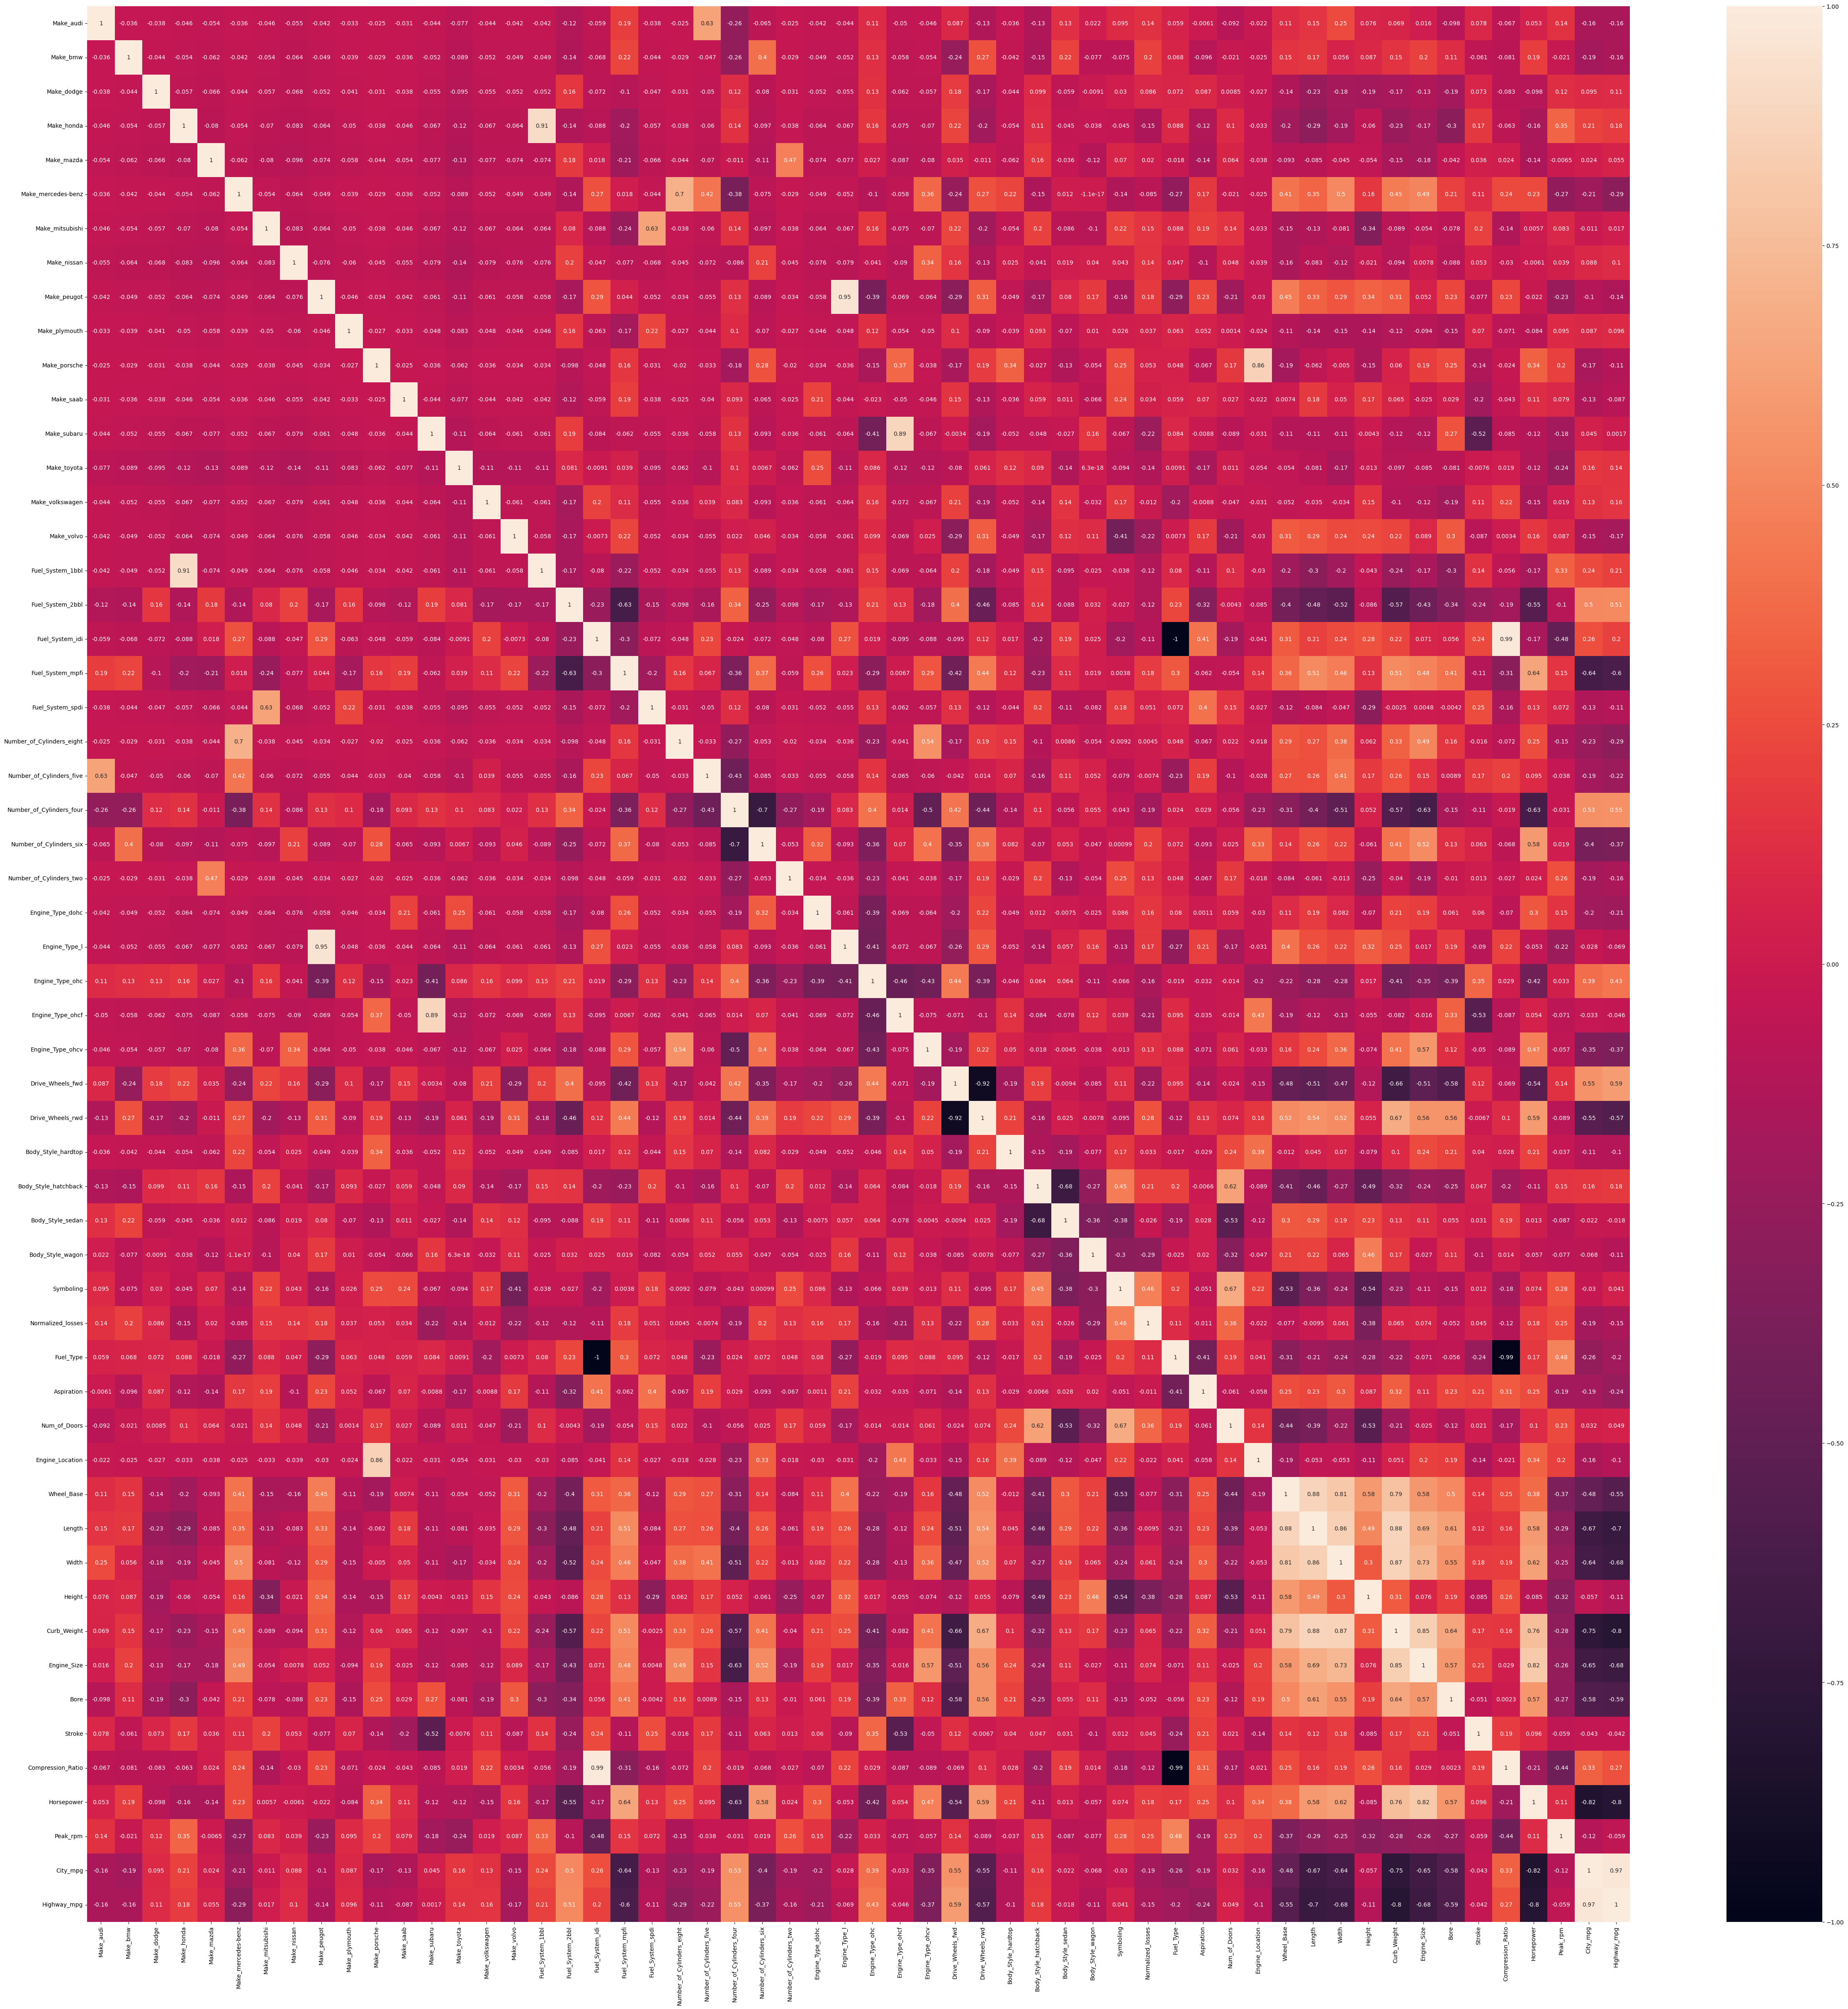

In [60]:
plt.figure(figsize=(60,60))
sns.heatmap(data=data.iloc[:,:-1].corr(),annot=True)
plt.show()

In [61]:
data.iloc[:,:-1].corr()

,Make_audi,Make_bmw,Make_dodge,Make_honda,Make_mazda,Make_mercedes-benz,Make_mitsubishi,Make_nissan,Make_peugot,Make_plymouth,Make_porsche,Make_saab,Make_subaru,Make_toyota,Make_volkswagen,Make_volvo,Fuel_System_1bbl,Fuel_System_2bbl,Fuel_System_idi,Fuel_System_mpfi,Fuel_System_spdi,Number_of_Cylinders_eight,Number_of_Cylinders_five,Number_of_Cylinders_four,Number_of_Cylinders_six,Number_of_Cylinders_two,Engine_Type_dohc,Engine_Type_l,Engine_Type_ohc,Engine_Type_ohcf,Engine_Type_ohcv,Drive_Wheels_fwd,Drive_Wheels_rwd,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Fuel_Type,Aspiration,Num_of_Doors,Engine_Location,Wheel_Base,Length,Width,Height,Curb_Weight,Engine_Size,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg
Make_audi,1.000000,-0.035898,-0.038175,-0.046369,-0.053601,-3.589791e-02,-0.046369,-0.055306,-0.042427,-0.033492,-0.025123,-0.030928,-0.044431,-7.675296e-02,-0.044431,-0.042427,-0.042427,-0.120641,-0.058621,0.192472,-0.038175,-0.025123,0.632084,-0.260383,-0.064942,-0.025123,-0.042427,-0.044431,0.108311,-0.050077,-0.046369,0.087008,-0.134774,-0.035898,-0.126224,0.128025,2.215667e-02,0.094608,0.136525,0.058621,-0.006103,-0.091902,-0.021702,0.113443,0.150481,0.247491,0.075637,0.069000,0.016113,-0.098203,0.078303,-0.067496,0.052823,0.140143,-0.160796,-0.160236
Make_bmw,-0.035898,1.000000,-0.044310,-0.053820,-0.062215,-4.166667e-02,-0.053820,-0.064194,-0.049245,-0.038874,-0.029161,-0.035898,-0.051571,-8.908708e-02,-0.051571,-0.049245,-0.049245,-0.140028,-0.068041,0.223402,-0.044310,-0.029161,-0.046829,-0.261163,0.395734,-0.029161,-0.049245,-0.051571,0.125716,-0.058124,-0.053820,-0.244866,0.266357,-0.041667,-0.146508,0.216762,-7.715167e-02,-0.074574,0.201905,0.068041,-0.095637,-0.020646,-0.025190,0.146218,0.170244,0.056149,0.087089,0.147449,0.196601,0.109832,-0.060537,-0.081316,0.194451,-0.021454,-0.185310,-0.159759
Make_dodge,-0.038175,-0.044310,1.000000,-0.057234,-0.066161,-4.430971e-02,-0.057234,-0.068266,-0.052368,-0.041340,-0.031010,-0.038175,-0.054842,-9.473815e-02,-0.054842,-0.052368,-0.052368,0.161320,-0.072357,-0.101471,-0.047120,-0.031010,-0.049800,0.115284,-0.080159,-0.031010,-0.052368,-0.054842,0.133691,-0.061811,-0.057234,0.180955,-0.166355,-0.044310,0.098776,-0.059440,-9.116183e-03,0.029630,0.085888,0.072357,0.086636,0.008538,-0.026787,-0.138280,-0.233338,-0.179165,-0.192401,-0.169686,-0.126406,-0.190537,0.072796,-0.083251,-0.098407,0.122535,0.094727,0.108569
Make_honda,-0.046369,-0.053820,-0.057234,1.000000,-0.080362,-5.382019e-02,-0.069519,-0.082918,-0.063609,-0.050214,-0.037666,-0.046369,-0.066614,-1.150724e-01,-0.066614,-0.063609,0.914986,-0.137393,-0.087888,-0.200183,-0.057234,-0.037666,-0.060489,0.140028,-0.097364,-0.037666,-0.063609,-0.066614,0.162386,-0.075078,-0.069519,0.219794,-0.202061,-0.053820,0.110463,-0.045107,-3.832909e-02,-0.045435,-0.145672,0.087888,-0.123532,0.101544,-0.032537,-0.197742,-0.288123,-0.190226,-0.060196,-0.233918,-0.174855,-0.303185,0.169813,-0.062866,-0.162584,0.350100,0.213048,0.184156
Make_mazda,-0.053601,-0.062215,-0.066161,-0.080362,1.000000,-6.221474e-02,-0.080362,-0.095852,-0.073530,-0.058046,-0.043541,-0.053601,-0.077004,-1.330207e-01,-0.077004,-0.073530,-0.073530,0.175261,0.017929,-0.206481,-0.066161,-0.043541,-0.069923,-0.011253,-0.112551,0.468709,-0.073530,-0.077004,0.027103,-0.086788,-0.080362,0.035359,-0.010769,-0.062215,0.159717,-0.035563,-1.151993e-01,0.070395,0.020336,-0.017929,-0.142800,0.064375,-0.037612,-0.092621,-0.084687,-0.045009,-0.054440,-0.151943,-0.175040,-0.042375,0.035601,0.024216,-0.144729,-0.006487,0.024030,0.055325
Make_mercedes-benz,-0.035898,-0.041667,-0.044310,-0.053820,-0.062215,1.000000e+00,-0.053820,-0.064194,-0.049245,-0.038874,-0.029161,-0.035898,-0.051571,-8.908708e-02,-0.051571,-0.049245,-0.049245,-0.140028,0.272166,0.018446,-0.044310,0.699854,0.421464,-0.384353,-0.075378,-0.029161,-0.049245,-0.051571,-0.102859,-0.058124,0.360181,-0.244866,0.266357,0.218750,-0.1

In [62]:
data.drop(["Length","Curb_Weight","Highway_mpg"],axis=1,inplace=True)

DATA SPLITTING

In [63]:
x = data.iloc[:,:-1]
x

,Make_audi,Make_bmw,Make_dodge,Make_honda,Make_mazda,Make_mercedes-benz,Make_mitsubishi,Make_nissan,Make_peugot,Make_plymouth,Make_porsche,Make_saab,Make_subaru,Make_toyota,Make_volkswagen,Make_volvo,Fuel_System_1bbl,Fuel_System_2bbl,Fuel_System_idi,Fuel_System_mpfi,Fuel_System_spdi,Number_of_Cylinders_eight,Number_of_Cylinders_five,Number_of_Cylinders_four,Number_of_Cylinders_six,Number_of_Cylinders_two,Engine_Type_dohc,Engine_Type_l,Engine_Type_ohc,Engine_Type_ohcf,Engine_Type_ohcv,Drive_Wheels_fwd,Drive_Wheels_rwd,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Fuel_Type,Aspiration,Num_of_Doors,Engine_Location,Wheel_Base,Width,Height,Engine_Size,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1.0,0.261780,1,0,1,0,0.058309,0.324786,0.083333,0.260377,0.664286,0.290476,0.12500,0.294393,0.346939,0.222222
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0.6,0.261780,1,0,1,0,0.230321,0.444444,0.383333,0.343396,0.100000,0.666667,0.12500,0.495327,0.346939,0.166667
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0.8,0.518325,1,0,0,0,0.384840,0.504274,0.541667,0.181132,0.464286,0.633333,0.18750,0.252336,0.551020,0.305556
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0.8,0.518325,1,0,0,0,0.373178,0.521368,0.541667,0.283019,0.464286,0.633333,0.06250,0.313084,0.551020,0.138889
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0.8,0.261780,1,0,1,0,0.384840,0.512821,0.441667,0.283019,0.464286,0.633333,0.09375,0.289720,0.551020,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0.2,0.157068,1,0,0,0,0.655977,0.735043,0.641667,0.301887,0.885714,0.514286,0.15625,0.308411,0.510204,0.277778
196,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0.2,0.157068,1,1,0,0,0.655977,0.726496,0.641667,0.301887,0.885714,0.514286,0.10625,0.523364,0.469388,0.166667
197,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0.2,0.157068,1,0,0,0,0.655977,0.735043,0.641667,0.422642,0.742857,0.380952,0.11250,0.401869,0.551020,0.138889
198,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0.2,0.157068,0,1,0,0,0.655977,0.735043,0.641667,0.316981,0.335714,0.633333,1.00000,0.271028,0.265306,0.361111


In [64]:
y = data.iloc[:,-1] 
y

0      0.282558
1      0.282558
2      0.219254
3      0.306142
4      0.251527
         ...   
195    0.291123
196    0.345738
197    0.406311
198    0.430763
199    0.434611
Name: Price, Length: 200, dtype: float64

In [65]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size = 0.8, random_state = 42)

In [66]:
x_train

,Make_audi,Make_bmw,Make_dodge,Make_honda,Make_mazda,Make_mercedes-benz,Make_mitsubishi,Make_nissan,Make_peugot,Make_plymouth,Make_porsche,Make_saab,Make_subaru,Make_toyota,Make_volkswagen,Make_volvo,Fuel_System_1bbl,Fuel_System_2bbl,Fuel_System_idi,Fuel_System_mpfi,Fuel_System_spdi,Number_of_Cylinders_eight,Number_of_Cylinders_five,Number_of_Cylinders_four,Number_of_Cylinders_six,Number_of_Cylinders_two,Engine_Type_dohc,Engine_Type_l,Engine_Type_ohc,Engine_Type_ohcf,Engine_Type_ohcv,Drive_Wheels_fwd,Drive_Wheels_rwd,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Fuel_Type,Aspiration,Num_of_Doors,Engine_Location,Wheel_Base,Width,Height,Engine_Size,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg
79,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1.0,0.261780,1,1,1,0,0.271137,0.512821,0.200000,0.358491,0.750000,0.852381,0.00000,0.453271,0.346939,0.166667
197,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0.2,0.157068,1,0,0,0,0.655977,0.735043,0.641667,0.422642,0.742857,0.380952,0.11250,0.401869,0.551020,0.138889
38,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0.4,0.104712,1,0,0,0,0.288630,0.188034,0.525000,0.184906,0.435714,0.719048,0.12500,0.177570,0.673469,0.388889
24,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0.6,0.434555,1,0,0,0,0.206997,0.299145,0.233333,0.109434,0.307143,0.552381,0.15000,0.093458,0.551020,0.500000
122,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,1.0,0.261780,1,0,1,1,0.084548,0.401709,0.316667,0.501887,0.857143,0.395238,0.15625,0.742991,0.714286,0.111111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0.4,0.261780,0,1,0,0,0.804665,0.692308,0.908333,0.343396,0.828571,0.690476,0.87500,0.219626,0.000000,0.333333
14,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0.4,0.261780,1,0,1,0,0.492711,0.649573,0.491667,0.558491,0.771429,0.628571,0.06250,0.626168,0.510204,0.083333
92,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0.6,0.298429,1,0,0,0,0.230321,0.299145,0.558333,0.135849,0.435714,0.580952,0.15000,0.098131,0.428571,0.500000
179,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0.8,0.151832,0,0,0,0,0.311953,0.444444,0.658333,0.135849,0.335714,0.633333,1.00000,0.018692,0.265306,0.666667


In [67]:
y_train

79     0.242068
197    0.406311
38     0.128519
24     0.061839
122    0.680453
         ...   
106    0.217020
14     0.898590
92     0.059108
179    0.071421
102    0.329701
Name: Price, Length: 160, dtype: float64

In [68]:
x_test

,Make_audi,Make_bmw,Make_dodge,Make_honda,Make_mazda,Make_mercedes-benz,Make_mitsubishi,Make_nissan,Make_peugot,Make_plymouth,Make_porsche,Make_saab,Make_subaru,Make_toyota,Make_volkswagen,Make_volvo,Fuel_System_1bbl,Fuel_System_2bbl,Fuel_System_idi,Fuel_System_mpfi,Fuel_System_spdi,Number_of_Cylinders_eight,Number_of_Cylinders_five,Number_of_Cylinders_four,Number_of_Cylinders_six,Number_of_Cylinders_two,Engine_Type_dohc,Engine_Type_l,Engine_Type_ohc,Engine_Type_ohcf,Engine_Type_ohcv,Drive_Wheels_fwd,Drive_Wheels_rwd,Body_Style_hardtop,Body_Style_hatchback,Body_Style_sedan,Body_Style_wagon,Symboling,Normalized_losses,Fuel_Type,Aspiration,Num_of_Doors,Engine_Location,Wheel_Base,Width,Height,Engine_Size,Bore,Stroke,Compression_Ratio,Horsepower,Peak_rpm,City_mpg
95,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0.4,0.214660,1,0,0,0,0.309038,0.418803,0.575000,0.222642,0.564286,0.666667,0.09375,0.228972,0.428571,0.388889
15,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0.4,0.261780,1,0,0,0,0.682216,0.905983,0.708333,0.558491,0.771429,0.628571,0.06250,0.626168,0.510204,0.055556
30,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0.6,0.188482,1,0,1,0,0.206997,0.316239,0.400000,0.067925,0.264286,0.476190,0.19375,0.056075,0.551020,0.694444
158,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0.6,0.539267,1,0,1,0,0.230321,0.316239,0.400000,0.139623,0.464286,0.457143,0.12500,0.102804,0.265306,0.444444
128,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0.8,0.204188,1,0,0,0,0.364431,0.529915,0.691667,0.226415,0.714286,0.476190,0.14375,0.289720,0.448980,0.222222
115,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0.6,0.282723,1,1,1,0,0.206997,0.299145,0.250000,0.139623,0.350000,0.628571,0.03750,0.252336,0.551020,0.305556
69,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0.4,0.261780,1,0,0,0,1.000000,0.974359,0.741667,0.932075,0.900000,0.609524,0.06250,0.635514,0.142857,0.027778
170,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0.2,0.000000,1,0,0,0,0.460641,0.529915,0.508333,0.230189,0.550000,0.700000,0.10625,0.205607,0.020408,0.388889
174,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,1.0,0.691099,1,0,1,0,0.475219,0.632479,0.350000,0.415094,0.521429,0.609524,0.14375,0.528037,0.428571,0.166667
45,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0.4,0.261780,1,0,1,0,0.448980,0.880342,0.000000,1.000000,0.714286,0.328571,0.28125,1.000000,0.346939,0.000000


In [69]:
y_test

95     0.095105
15     0.788491
30     0.006976
158    0.072985
128    0.175066
115    0.070478
69     0.889777
170    0.120898
174    0.270096
45     0.766645
66     0.657415
182    0.108659
165    0.150961
78     0.186460
186    0.202994
177    0.065960
56     0.083834
152    0.051636
82     0.076238
68     0.743210
124    0.792165
16     0.000819
148    0.044685
93     0.071521
65     0.572414
60     0.152103
84     0.103297
67     0.721563
125    0.103694
132    0.335187
9      0.293109
18     0.036170
55     0.092523
75     0.063825
150    0.090859
104    0.200636
135    0.061690
137    0.065960
164    0.120922
76     0.120178
Name: Price, dtype: float64

PRINCIPAL COMPONENT ANALYSIS (PCA)

In [70]:
from sklearn.decomposition import PCA
pca=PCA(n_components=0.95)
pca_x_train=pca.fit_transform(x_train)
pca_x_test=pca.transform(x_test)
print(pca_x_train.shape)
print(pca_x_test.shape)

(160, 23)
(40, 23)


# MODEL CREATION 
LINEAR REGRESSION

In [71]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression() 
lr_model.fit(pca_x_train, y_train)

LinearRegression()

In [72]:
y_pred_linear = lr_model.predict(pca_x_test)
y_pred_linear

array([ 0.05136701,  0.58702436,  0.03507644,  0.07359999,  0.26287215,
        0.0714617 ,  0.66013074,  0.10439294,  0.3785222 ,  0.47187636,
        0.63121756,  0.12842021,  0.30796779,  0.19945651,  0.30246138,
        0.0950063 ,  0.17495435, -0.01255539,  0.13211706,  0.53024537,
        0.56783357,  0.02186721, -0.02031423, -0.02173268,  0.71947251,
        0.15752985,  0.10513435,  0.57736887,  0.17017362,  0.31608512,
        0.23693324,  0.05134881,  0.15618674,  0.07734761,  0.00468724,
        0.29915521,  0.10361683,  0.09454932,  0.17923121,  0.10894151])

In [73]:
from sklearn.metrics import *
r2 = r2_score(y_test, y_pred_linear)
r2

0.8399885000916791

In [115]:
linear_reg_r2 = r2_score(y_test, y_pred_linear)
print(f'r2_score (Linear Regression) : {linear_reg_r2}')

r2_score (Linear Regression) : 0.8399885000916791


DECISION TREE

In [74]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
model=dt.fit(pca_x_train,y_train)
model

DecisionTreeRegressor()

In [75]:
y_pred_dtr=model.predict(pca_x_test)
print(f'R2_score (Decision Tree) : {r2_score(y_test,y_pred_dtr)}')
print(f'mean_squared_error       : {mean_squared_error(y_test,y_pred_dtr)}')
print(f'mean_absolute_error      : {mean_absolute_error(y_test,y_pred_dtr)}')
print(f'root_mean_square_error   : {np.sqrt(mean_squared_error(y_test,y_pred_dtr))}')

R2_score (Decision Tree) : 0.8856330559565474
mean_squared_error       : 0.007897386040129514
mean_absolute_error      : 0.061272404547937045
root_mean_square_error   : 0.08886723828346144


HYPERPARAMETER TUNING (DECISION TREE)

In [76]:
params={'splitter':["best", "random"],
        'criterion':["squared_error", "absolute_error"],
        'max_depth':list(range(1,20)),
        'min_samples_split':list(range(1,10)),
        'min_samples_leaf':list(range(1,10))}

tree_reg=DecisionTreeRegressor()
tree_cv=RandomizedSearchCV(tree_reg,param_distributions=params,scoring='r2',n_jobs=-1,verbose=3,cv=3,n_iter=300)
tree_cv.fit(pca_x_train,y_train)

Fitting 3 folds for each of 300 candidates, totalling 900 fits


RandomizedSearchCV(cv=3, estimator=DecisionTreeRegressor(), n_iter=300,
                   n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'absolute_error'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9],
                                        'min_samples_split': [1, 2, 3, 4, 5, 6,
                                                              7, 8, 9],
                                        'splitter': ['best', 'random']},
                   scoring='r2', verbose=3)

In [77]:
best_params=tree_cv.best_params_
print(f'best parameters:{best_params}')

best parameters:{'splitter': 'best', 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_depth': 16, 'criterion': 'squared_error'}


In [78]:
dt=DecisionTreeRegressor(splitter='random', min_samples_split=5, min_samples_leaf=1, max_depth=15, criterion='absolute_error')
dt.fit(pca_x_train,y_train)
y_pred=dt.predict(pca_x_test)
decisiontree_reg_r2=r2_score(y_test,y_pred)
print(f'r2_score (decision tree):{decisiontree_reg_r2}')

r2_score (decision tree):0.6543972439079626


RANDOM FOREST

In [79]:
from sklearn.ensemble import RandomForestRegressor
RFR=RandomForestRegressor()
RFR.fit(pca_x_train,y_train)

RandomForestRegressor()

In [80]:
y_pred_rfr=RFR.predict(pca_x_test)

In [81]:
print(f'r2_score (random forest) : {r2_score(y_test,y_pred_rfr)}')
print(f'mean_squared_error       : {mean_squared_error(y_test,y_pred_rfr)}')
print(f'mean_absolute_error      : {mean_absolute_error(y_test,y_pred_rfr)}')
print(f'root_mean_squared_error  : {np.sqrt(mean_squared_error(y_test,y_pred_rfr))}')

r2_score (random forest) : 0.6872273503782594
mean_squared_error       : 0.02159790468755175
mean_absolute_error      : 0.08729478209870414
root_mean_squared_error  : 0.14696225599640117


HYPERPARAMETER TUNING (RANDOM FOREST)

In [82]:
params={'n_estimators':[100,150,200,250,300],
        'max_features':['auto','sqrt','log2'],
        'max_depth':list(range(1,40)),
        'min_samples_split':list(range(1,20)),
        'min_samples_leaf':list(range(1,20)),
        'criterion': ['squared_error',"friedman_mse", "absolute_error","poisson"]}

rf_cv=RandomizedSearchCV(RFR,param_distributions=params,scoring='r2',n_jobs=-1,verbose=3,cv=5,n_iter=500)
rf_cv.fit(pca_x_train,y_train)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=500,
                   n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'friedman_mse',
                                                      'absolute_error',
                                                      'poisson'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20, 21,
                                                      22, 23, 24, 25, 26, 27,
                                                      28, 29, 30, ...],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10, 11,
                                                             12, 13, 14, 15, 16,
                                                             17, 18, 19],
                                        'min_samples_split': [1, 2, 3, 4, 5, 6,
                                                              7, 8, 9, 10, 11,
                                                              12, 13, 14, 15,
                                                              16, 17, 18, 19],
                                        'n_estimators': [100, 150, 200, 250,
                                                         300]},
                   scoring='r2', verbose=3)

In [84]:
best_params=rf_cv.best_params_
print(f'best parameters:{best_params}')

best parameters:{'n_estimators': 200, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 32, 'criterion': 'poisson'}


In [87]:
rf_best=RandomForestRegressor(n_estimators=250, min_samples_split=4, min_samples_leaf=1, max_features='sqrt', max_depth=22, criterion='absolute_error')
rf_best.fit(pca_x_train,y_train)
y_pred_rfr_best=rf_best.predict(pca_x_test)
randomforest_reg_r2=r2_score(y_test,y_pred_rfr_best)
print(randomforest_reg_r2)

0.6711237611485428


#  GRADIENT BOOSTING

In [85]:
GBR=GradientBoostingRegressor()
GBR.fit(pca_x_train,y_train)
y_pred_gbr=GBR.predict(pca_x_test)
print(f' r2_score(gradient boosting) : {r2_score(y_test,y_pred_gbr)}')
print(f' mean_absolute_error         : {mean_absolute_error(y_test,y_pred_gbr)}')
print(f' mean_squared_error          : {mean_squared_error(y_test,y_pred_gbr)}')
print(f' root_mean_squared_error     : {mean_squared_error(y_test,y_pred_gbr)}')

 r2_score(gradient boosting) : 0.8561330105789844
 mean_absolute_error         : 0.06635869368152295
 mean_squared_error          : 0.00993445408016945
 root_mean_squared_error     : 0.00993445408016945


## HYPERPARAMETER TUNING (GRADIENT BOOSTING)

In [86]:
params={'n_estimators':[100,200,300],
        'learning_rate':[0.001,0.01,0.02,0.03,0.1],
        'max_depth':list(range(1,20)),
        'min_samples_split':list(range(1,10)),
        'min_samples_leaf':list(range(1,10)),
       }

gb_cv=RandomizedSearchCV(estimator=GBR,scoring='r2',param_distributions=params,cv=5,verbose=2,n_jobs=-1,n_iter=300)
gb_cv.fit(pca_x_train,y_train)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_iter=300,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.001, 0.01, 0.02,
                                                          0.03, 0.1],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9],
                                        'min_samples_split': [1, 2, 3, 4, 5, 6,
                                                              7, 8, 9],
                                        'n_estimators': [100, 200, 300]},
                   scoring='r2', verbose=2)

In [88]:
best_params=gb_cv.best_params_
print(f'best_params:{best_params}')

best_params:{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.03}


In [89]:
gbr_best=GradientBoostingRegressor(n_estimators=300, min_samples_split=6, min_samples_leaf=1, max_depth=3, learning_rate=0.03)
gbr_best.fit(pca_x_train,y_train)
y_pred_gbr_best=gbr_best.predict(pca_x_test)
gradboost_reg_r2=r2_score(y_test,y_pred_gbr_best)
print(gradboost_reg_r2)

0.8480169990431844


#  XGBOOSTING

In [90]:
xgb=XGBRegressor()
xgb.fit(pca_x_train,y_train)
y_pred_xgb=xgb.predict(pca_x_test)
print(f' r2_score (xgboost)      : {r2_score(y_test,y_pred_xgb)}')
print(f' mean_absolute_error     : {mean_absolute_error(y_test,y_pred_xgb)}')
print(f' mean_squared_error      : {mean_squared_error(y_test,y_pred_xgb)}')
print(f' root_mean_squared_error : {mean_squared_error(y_test,y_pred_xgb)}')

 r2_score (xgboost)      : 0.71928052106333
 mean_absolute_error     : 0.0856486198994516
 mean_squared_error      : 0.01938453556391767
 root_mean_squared_error : 0.01938453556391767


##  HYPERPARAMETER TUNING (XGBOOSTING)

In [98]:
xg_param_grid = {"gamma":[0,0.1,0.2,0.4],
             "learning_rate":[0.01,0.02,0.03,0.04,0.05,0.06,0.1],
             "max_depth":list(range(1,11)),
             "n_estimators":[50,65,80,100,150],
             "alpha":[0,0.1,0.5,1],
            }

In [99]:
XGB = XGBRegressor()
rcv = GridSearchCV(estimator=XGB, scoring="r2", param_grid=xg_param_grid , cv=5, verbose=3,n_jobs=-1)

In [100]:
rcv.fit(pca_x_train, y_train)

Fitting 5 folds for each of 5600 candidates, totalling 28000 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'alpha': [0, 0.1, 0.5, 1], 'gamma': [0, 0.1, 0.2, 0.4],
                         'learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06,
                                           0.1],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'n_estimators': [50, 65, 80, 100, 150]},
             scoring='r2', verbose=3)

In [101]:
cv_best_params = rcv.best_params_
print(f"Best parameters: {cv_best_params}")

Best parameters: {'alpha': 1, 'gamma': 0, 'learning_rate': 0.06, 'max_depth': 6, 'n_estimators': 150}


In [102]:
xgb_model=XGBRegressor(alpha=1, gamma=0,learning_rate=0.06, max_depth=6, n_estimators=150)
xgb_model.fit(pca_x_train,y_train)
xg1_y_pred=xgb_model.predict(pca_x_test)
xgb_reg_r2=(r2_score(y_test,xg1_y_pred))
print(xgb_reg_r2)

0.848886607621127


## K-NEAREST NEIGHBORS (KNN)

In [103]:
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(pca_x_train,y_train)
y_pred_knn=knn.predict(pca_x_test)
from sklearn.metrics import *
print(f' r2_score (knn)          : {r2_score(y_test,y_pred_knn)}')
print(f' mean_absolute_error     : {mean_absolute_error(y_test,y_pred_knn)}')
print(f' mean_squared_error      : {mean_squared_error(y_test,y_pred_knn)}')
print(f' root_mean_squared_error : {mean_squared_error(y_test,y_pred_knn)}')

 r2_score (knn)          : 0.8358669266473322
 mean_absolute_error     : 0.0710417804478427
 mean_squared_error      : 0.011333888940203088
 root_mean_squared_error : 0.011333888940203088


## HYPERPARAMETER TUNING (KNN)

In [104]:
param_grid={'n_neighbors':[3,5,7,9,11],
            'weights':['uniform','distance'],
            'algorithm':['auto','ball_tree','kd_tree','brute'],
            'p':[1,2]}
knn1=RandomizedSearchCV(estimator=KNeighborsRegressor(),param_distributions=param_grid,scoring='r2',n_jobs=-1,verbose=3,cv=3,n_iter=5000)
knn1.fit(pca_x_train,y_train)

Fitting 3 folds for each of 80 candidates, totalling 240 fits


RandomizedSearchCV(cv=3, estimator=KNeighborsRegressor(), n_iter=5000,
                   n_jobs=-1,
                   param_distributions={'algorithm': ['auto', 'ball_tree',
                                                      'kd_tree', 'brute'],
                                        'n_neighbors': [3, 5, 7, 9, 11],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   scoring='r2', verbose=3)

In [105]:
best_params=knn1.best_params_
print(f'best_parameters:{best_params}')

best_parameters:{'weights': 'distance', 'p': 2, 'n_neighbors': 11, 'algorithm': 'auto'}


In [106]:
knn_model=KNeighborsRegressor(weights='distance', p= 2, n_neighbors=11, algorithm='auto')
knn_model.fit(pca_x_train,y_train)
y_pred=knn_model.predict(pca_x_test)
knn_reg_r2=r2_score(y_test,y_pred)
print(knn_reg_r2)

0.7556189115951665


## ARTIFICIAL NEURAL NETWORK (ANN)

In [107]:
model_ann=MLPRegressor()
model_ann.fit(pca_x_train,y_train)
y_pred=model_ann.predict(pca_x_test)
MLP_reg_r2=r2_score(y_test,y_pred)
print('The R2_score is ',MLP_reg_r2)

The R2_score is  0.8585366699223427


## HYPERPARAMETER TUNING (ANN)

In [109]:
params_ann={'learning_rate_init':[0.001,0.002,0.005,0.01,0.1,0.2,0.5,1],
       'max_iter':[100,200,300,400,500,1000,2000,3000]
       }

In [110]:
ann_cv=GridSearchCV(estimator=model_ann,param_grid=params_ann,scoring='r2',n_jobs=-1,cv=5,verbose=3)
ann_cv.fit(pca_x_train,y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5, estimator=MLPRegressor(), n_jobs=-1,
             param_grid={'learning_rate_init': [0.001, 0.002, 0.005, 0.01, 0.1,
                                                0.2, 0.5, 1],
                         'max_iter': [100, 200, 300, 400, 500, 1000, 2000,
                                      3000]},
             scoring='r2', verbose=3)

In [111]:
ann_best_params=ann_cv.best_params_
print(f'best_parameters:{ann_best_params}')

best_parameters:{'learning_rate_init': 0.01, 'max_iter': 300}


In [112]:
ann_model=MLPRegressor(learning_rate_init=0.01, max_iter=300)
ann_model.fit(pca_x_train,y_train)

MLPRegressor(learning_rate_init=0.01, max_iter=300)

In [113]:
ann_y_pred=ann_model.predict(pca_x_test)
ann_reg_r2=r2_score(y_test,ann_y_pred)
print(ann_reg_r2)

0.8930976516403099


## MODEL COMPARISON REPORT

In [116]:
comparison_dict = {
    'Model': ['LinearRegression', 'DecisionTreeRegressor', 'RandomForestRegressor', 'GBRegressor', 'XGBRegressor','KNeighborsRegressor', 'MLPRegressor'],
    'R2_score': [linear_reg_r2, decisiontree_reg_r2, randomforest_reg_r2, gradboost_reg_r2, xgb_reg_r2,knn_reg_r2, ann_reg_r2]
}

# Creating DataFrame
comparison_df = pd.DataFrame(comparison_dict)
print(comparison_df)

                   Model  R2_score
0       LinearRegression  0.839989
1  DecisionTreeRegressor  0.654397
2  RandomForestRegressor  0.671124
3            GBRegressor  0.848017
4           XGBRegressor  0.848887
5    KNeighborsRegressor  0.755619
6           MLPRegressor  0.893098


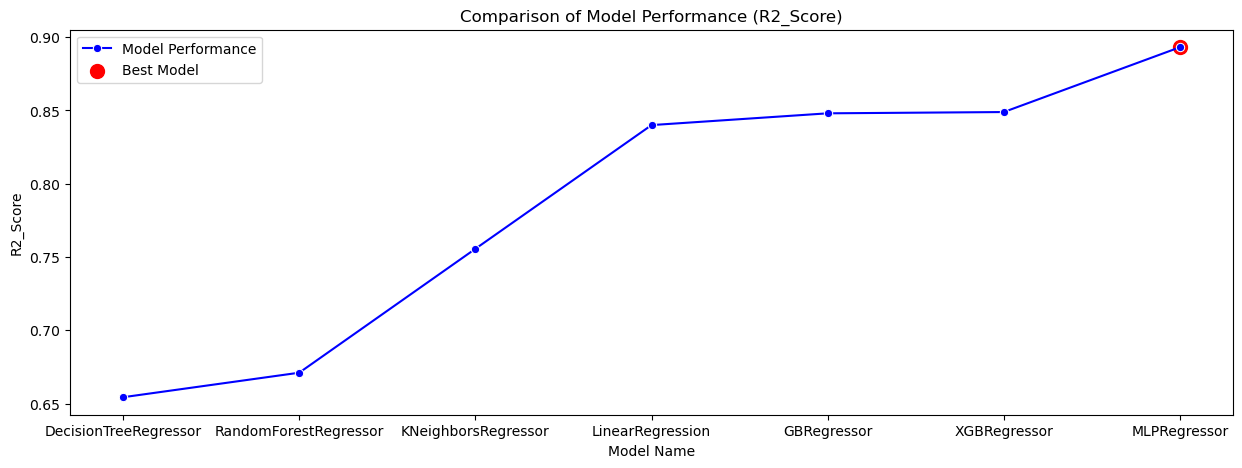

In [117]:
comparison_df = comparison_df.sort_values(by='R2_score', ascending=True)


max_index = comparison_df['R2_score'].idxmax()  # This returns the row index having highest r2_score


plt.figure(figsize=(15, 5))
sns.lineplot(data=comparison_df, x='Model', y='R2_score', marker='o', color='blue', label="Model Performance")


plt.scatter(comparison_df.loc[max_index, 'Model'], comparison_df.loc[max_index, 'R2_score'],color='red', s=100, label="Best Model")


plt.xlabel("Model Name")
plt.ylabel("R2_Score")

plt.legend()
plt.title("Comparison of Model Performance (R2_Score)")
plt.show()